In [2]:
%load_ext autoreload
%autoreload 2
import torch
from torch import nn
import Systems
import numpy as np
from NN import Main_Network
import matplotlib.pyplot as plt
from Dataset import DataSet
from Normalizer import Normalizer
from Trainer import Trainer
import scipy.io as spio
from torch.optim.lr_scheduler import ReduceLROnPlateau
from Observer_old import System_z, Observer
import torch.nn.functional as F

In [3]:
# --------------------- Reverse Duffing Oscillator --------------------- 

limits_normal = np.array([[-1, 1], [-1, 1]])    # Sample space for normal datapoints
a = 0   # start
b = 50  # end
N = 1000          # Number of intervals for RK4
num_ic = 60       # Number of initial conditions to be sampled
num_val_ic = round(num_ic*0.2)      # Select 20% of the dataset for validation

M = np.diag([-1,-2,-3,-4,-5])    # Choose M matrix
K = np.array([[1,1,1,1,1]]).T    # Choose K matrix

revduff = Systems.RevDuff(5, add_noise=False)
trainset = DataSet(revduff, M, K, a, b, N, num_ic - num_val_ic, limits_normal, 8888, PINN_sample_mode = 'split traj', data_gen_mode = 'negative forward')
valset = DataSet(revduff, M, K, a, b, N, num_val_ic, limits_normal, 88888, PINN_sample_mode = 'split traj', data_gen_mode = 'negative forward')

(48, 1001, 2)
(12, 1001, 2)


In [3]:
# --------------------- Non-Autonomous Reverse Duffing Oscillator --------------------- 
def u(t):
    return 1e-3 + 9.99*1e-5*t

limits = np.array([[-1,1], [-1,1]])    # Sample space
a = 0   # start
b = 50  # end
N = 1000          # Number of intervals for RK4
num_ic = 50        # Number of initial conditions to be sampled
M = np.diag([-1,-2,-3])    # Choose M matrix
K = np.array([[1,1,1]]).T    # Choose K matrix

revduff_na = Systems.RevDuff_NA(limits, u)      # Create system

dataset = training_data.DataSet(revduff_na, M, K, a, b, N, num_ic)
dataset.normalize()
trainset = torch.utils.data.DataLoader(dataset, batch_size = 32, shuffle = True)

In [2]:
# --------------------- Network SIS ---------------------
np.random.seed(1)

a = [1]*10    # 10 dimensional system

B = np.diag(a)*np.random.rand(10,10)

G = np.diag(a)*np.random.rand(10,10)

#A = np.diag(a)
#del a[-1]
#A = (A + np.diag(a, 1) + np.diag(a, -1))*np.random.rand(10,10)
A = np.random.randint(2, size=(10,10))*np.random.rand(10,10)

C = np.concatenate((np.eye(3),np.zeros((3,7))), axis = 1)

limits = np.concatenate((np.zeros([10,1]), np.ones([10,1])), axis = 1)    # Sample space
a = 0   # start
b = 50  # end
N = 1000        # Number of intervals for RK4
num_ic = 50       # Number of initial conditions to be sampled

# Load controllable pair (M,K) from MATLAB
mat = spio.loadmat('/Users/johncao/Documents/MATLAB/MK.mat', squeeze_me=True)
M = mat['M']
K = mat['K']

SIS = Systems.SIS(limits,A,B,G,C)    # Create and initiate the system

train = training_data.DataSet(SIS, M, K, a, b, N, limits, num_ic)
trainset = torch.utils.data.DataLoader(train, batch_size = 32, shuffle = True)

(50, 1001, 3)


In [2]:
# --------------------- Van der Pol Oscillator ---------------------

limits_normal = np.array([[-1,1], [-1,1]])    # Sample space
a = 0   # start
b = 50  # end
N = 1000          # Number of intervals for RK4
num_ic = 50        # Number of initial conditions to be sampled

# M = np.diag([-1,-2,-3])    # Choose M matrix
# K = np.array([[1,1,1]]).T    # Choose K matrix

mat = spio.loadmat('/Applications/Programming/Machine Learning/DF Internship/MK_data/Duffing_ML_dim5', squeeze_me=True)
M = mat['M']
K = np.expand_dims(mat['L'], axis = 0).T

vdp = Systems.VdP(zdim = 5, my = 3)

dataset = DataSet(vdp, M, K, a, b, N, num_ic, limits_normal, PINN_sample_mode = 'split traj', data_gen_mode = 'negative forward')


In [2]:
# --------------------- VDP params---------------------

limits_normal = np.array([[-1,1], [-1,1], [1, 5]])    # Sample space
a = 0   # start
b = 50  # end
N = 1000          # Number of intervals for RK4
num_ic = 60       # Number of initial conditions to be sampled
num_val_ic = round(num_ic*0.2)      # Select 20% of the dataset for validation

M = np.diag([-1, -2, -3, -4, -5, -6, -7, -8])*1
K = np.ones([8,1])

# Input mask T
ones_Tin = torch.ones(2,10)
zeros_Tin = torch.zeros(3,50, dtype=torch.bool)
zeros_Tin[0:2, 40:] = ones_Tin
mask_Tin = zeros_Tin

# Output mask T
ones_Tout = torch.ones(40, 3)
zeros_Tout = torch.zeros(50,8, dtype = torch.bool)
zeros_Tout[0:40, 5:] = ones_Tout
mask_Tout = zeros_Tout

# Input mask T_star
ones_Tin_star = torch.ones(5, 10)
zeros_Tin_star = torch.zeros(8,50, dtype = torch.bool)
zeros_Tin_star[0:5, 40:] = ones_Tin_star
mask_Tin_star = zeros_Tin_star

# Output mask T_star
ones_T_star = torch.ones(40,1)
zeros_Tout_star = torch.zeros(50,3, dtype = torch.bool)
zeros_Tout_star[0:40, 2:] = ones_T_star
mask_Tout_star = zeros_Tout_star

# Hidden mask
ones_h = torch.ones(40,10)
zeros_h = torch.zeros(50,50, dtype=torch.bool)
zeros_h[0:40, 40:] = ones_h
mask_hidden = zeros_h

mask_T = {'hidden':mask_hidden, 'input':mask_Tin, 'output': mask_Tout}
mask_T_star = {'hidden':mask_hidden, 'input':mask_Tin_star, 'output': mask_Tout_star}
mask = {'T':mask_T, 'T_star':mask_T_star}

vdp_params = Systems.Vdp_params()
trainset = DataSet(vdp_params, M, K, a, b, N, num_ic - num_val_ic, limits_normal, 8888, PINN_sample_mode = 'split traj', data_gen_mode = 'negative forward')
valset = DataSet(vdp_params, M, K, a, b, N, num_val_ic, limits_normal, 88888, PINN_sample_mode = 'split traj', data_gen_mode = 'negative forward')

In [2]:
# --------------------- Non-Autonomous Van der Pol Oscillator ---------------------

# Excitation
def u(t):
    return 1e-3 + 9.99*1e-5*t

limits = np.array([[-1,1], [-1,1]])    # Sample space
vdp_na = Systems.VdP_NA(limits, u, 1)
a = 0   # start
b = 50  # end
N = 1000          # Number of intervals for RK4
num_ic = 50        # Number of initial conditions to be sampled
M = np.diag([-1,-2,-3])    # Choose M matrix
K = np.array([[1,1,1]]).T    # Choose K matrix

dataset = training_data.DataSet(vdp_na, M, K, a, b, N, num_ic)
#dataset.normalize()
trainset = torch.utils.data.DataLoader(dataset, batch_size = 32, shuffle = True)


In [2]:
# --------------------- Polynomial ---------------------

limits = np.array([[-1,1], [-1,1]])    # Sample space
a = 0   # start
b = 50  # end
N = 1000        # Number of intervals for RK4
num_ic = 50        # Number of initial conditions to be sampled
M = np.diag([-1,-2,-3])    # Choose M matrix
K = np.array([[1,1,1]]).T    # Choose K matrix
poly = Systems.Polynomial(limits)

train = training_data.DataSet(poly, M, K, a, b, N, limits, num_ic)
trainset = torch.utils.data.DataLoader(train, batch_size = 32, shuffle = True)

In [2]:
# Chua's Circuit

alpha = 11.81
beta = 14.9
gamma = 0.29
limits_normal = np.array([[-0.1,0.1], [-0.1,0.1], [-0.1,0.1]])       
a = 0   # start
b = 50  # end
N = 1000        # Number of intervals for RK4
num_ic = 60
num_val_ic = round(num_ic*0.2)      # Select 20% of the dataset for validation
# M = np.diag([-1,-2,-3,-4])    # Choose M matrix
# K = np.array([[1,1,1,1]]).T    # Choose K matrix

mat = spio.loadmat('/Applications/Programming/Machine Learning/DF Internship/MK_data/Chua_ML', squeeze_me=True)
M = mat['M']
K = np.expand_dims(mat['L'], axis = 0).T

chua = Systems.Chua(alpha, beta, gamma, -1.14, -0.71)

trainset = DataSet(chua, M, K, a, b, N, num_ic - num_val_ic, limits_normal,888, PINN_sample_mode = 'split traj', data_gen_mode = 'negative forward')
valset = DataSet(chua, M, K, a, b, N, num_val_ic, limits_normal, 88888, PINN_sample_mode = 'split traj', data_gen_mode = 'negative forward')

In [2]:
# Smooth Chua's cicuit

alpha = 8.4562
beta = 12.0732
gamma = 0.0052
m0 = 0.3532
m1 = -1.1468
limits_normal = np.array([[-1,1], [-1,1], [-1,1]])    

a = 0   # start
b = 50  # end
N = 1000        # Number of intervals for RK4
num_ic = 50

# M = np.diag([-1,-2,-3,-4])    # Choose M matrix
# K = np.array([[1,1,1,1]]).T    # Choose K matrix

mat = spio.loadmat('/Applications/Programming/Machine Learning/DF Internship/MK_data/Chua_ML', squeeze_me=True)
M = mat['M']
K = np.expand_dims(mat['L'], axis = 0).T

chua = Systems.Chua_Smooth(alpha, beta, gamma, m0, m1)
dataset = DataSet(chua, M, K, a, b, N, num_ic, limits_normal, PINN_sample_mode = 'split traj', data_gen_mode = 'negative forward')

In [2]:
# Rössler's System

a0 = 0.2
b0 = 0.2
c0 = 5.7

a = 0   # start
b = 50  # end
N = 1000        # Number of intervals for RK4
num_ic = 60
num_val_ic = round(num_ic*0.2) 
# mat = spio.loadmat('/Applications/Programming/Machine Learning/DF Internship/MK_data/MK_Rossler', squeeze_me=True)
# M = mat['M']
# K = mat['K'].reshape(4,1)
mat = spio.loadmat('/Applications/Programming/Machine Learning/DF Internship/MK_data/Chua_ML', squeeze_me=True)
M = mat['M']
K = np.expand_dims(mat['L'], axis = 0).T

limits = limits = np.array([[-1,1], [-1,1], [-1,1]])    # Sample space
rossler = Systems.Rossler(a0, b0, c0, noise_std = 1)

trainset = DataSet(rossler, M, K, a, b, N, num_ic, limits, 888, PINN_sample_mode = 'split traj', data_gen_mode = 'negative forward')
valset = DataSet(rossler, M, K, a, b, N, num_val_ic, limits, 88888, PINN_sample_mode = 'split traj', data_gen_mode = 'negative forward')

In [2]:
# Rössler's System with changing parameters

a = 0   # start
b = 30  # end
N = 1000        # Number of intervals for RK4
num_ic = 60
num_val_ic = round(num_ic*0.2) 
# mat = spio.loadmat('/Applications/Programming/Machine Learning/DF Internship/MK_data/MK_Rossler', squeeze_me=True)
# M = mat['M']
# K = mat['K'].reshape(4,1)
# mat = spio.loadmat('/Applications/Programming/Machine Learning/DF Internship/MK_data/Chua_ML', squeeze_me=True)
# M = mat['M']
# K = np.expand_dims(mat['L'], axis = 0).T

M = -np.diag(np.arange(1,27))*0.2
K = np.ones([26,2])

#limits = np.array([[-1,1], [-1,1], [-1,1], [0.15, 0.3], [0.15, 0.3], [1, 5]])    # Sample space
limits = np.array([[-1,1], [-1,1], [-1,1], [0.2, 0.21], [0.2, 0.21], [1, 5]])    # Sample space
rossler_params = Systems.Rossler_params(noise_std = 1)

trainset = DataSet(rossler_params, M, K, a, b, N, num_ic, limits, 888, PINN_sample_mode = 'split traj', data_gen_mode = 'negative forward')
valset = DataSet(rossler_params, M, K, a, b, N, num_val_ic, limits, 88888, PINN_sample_mode = 'split traj', data_gen_mode = 'negative forward')

In [2]:
# Lorenz System

rho = 28
sigma = 10
beta = 8/3

a = 0
b = 50
N = 1000
num_ic = 50

mat = spio.loadmat('/Applications/Programming/Machine Learning/DF Internship/MK_data/Chua_ML', squeeze_me=True)
M = mat['M']
K = np.expand_dims(mat['L'], axis = 0).T
limits = limits = np.array([[-1,1], [-1,1], [-1,1]])    # Sample space
lorenz = Systems.Lorenz(rho, sigma, beta)

dataset = DataSet(lorenz, M, K, a, b, N, num_ic, limits, PINN_sample_mode = 'split traj', data_gen_mode = 'negative forward')


In [2]:
# SIR

beta = 0.5
gamma = 0.05
limits = np.array([[0,1], [0,1], [0,1]])    # Sample space

mat = spio.loadmat('/Applications/Programming/Machine Learning/DF Internship/MK_data/MK_SIR', squeeze_me=True)
M = mat['M']
K = mat['K']

a = 0   # start
b = 50  # end
N = 1000        # Number of intervals for RK4
num_ic = 50

sir = Systems.SIR(limits, beta, gamma, 1)

train = DataSet(sir, M, K, a, b, N, limits, num_ic)

In [2]:
# --------------------- Network SIR --------------------- 

mat = spio.loadmat('/Applications/Programming/Machine Learning/DF Internship/MK_data/SIR_net', squeeze_me=True)
M = mat['A']
K = mat['B']
C = mat['C']
D = mat['D']
W = mat['W']
G = mat['G']
net_sir = Systems.Network_SIR(D, W, G, C)

limits_S = np.concatenate((np.zeros([5,1]), np.ones([5,1])), axis = 1)*0.8
limits_I = np.concatenate((np.zeros([5,1]), np.ones([5,1])), axis = 1)*0.2
limits = np.concatenate((limits_S, limits_I), axis = 0)

num_ic = 50
a = 0
b = 50
N = 1000

dataset = DataSet(net_sir, M, K, a, b, N, num_ic, limits, PINN_sample_mode = 'split traj', data_gen_mode='negative forward')

In [2]:
# --------------------- SIR Epidemic --------------------- 
a = 0
b = 50
N = 1000
limits = np.array([[0.9, 1], [0, 0.1], [0, 1], [0, 0.5]])
A = np.diag(-np.arange(1,10))*0.2
B = np.ones([9,1])
num_ic = 100       # Number of initial conditions to be sampled
num_val_ic = round(num_ic*0.2)      # Select 20% of the dataset for validation
epidemic_sir = Systems.epidemic_SIR()

trainset = DataSet(epidemic_sir, A, B, a, b, N, num_ic, limits, 8888, PINN_sample_mode = 'split traj', data_gen_mode = 'negative forward')
valset = DataSet(epidemic_sir, A, B, a, b, N, num_val_ic, limits, 88888, PINN_sample_mode = 'split traj', data_gen_mode = 'negative forward')


In [2]:
# --------------------- CSTR --------------------- 

Fs = 1.2
V = 500
k0 = 1/7.2*10**-10  
EdivR = 10**4
T0 = 350
Tj0 = 350
delta_H = -2*10**5
Cp = 1
Cpj = 1
rho = 10**3
rho_j = 10**3
C0 = 0.5
ha = 7.2*10**5
Cs = 0.48459
Ts = 351.52
Fjs = 5
k1 = -delta_H*k0 / (rho*Cp)
k2 = 1 / V
k3 = ha / (rho*Cp)

a = 0
b = 100
N = 1000

CSTR = Systems.CSTR(Fs, Fjs, V, C0, Cs, T0, Ts, Tj0, k0, k1, k2, k3, EdivR)

limits_normal = np.array([[0, 1], [0, 2]])    # Sample space for normal datapoints
num_ic = 60       # Number of initial conditions to be sampled
num_val_ic = round(num_ic*0.2)      # Select 20% of the dataset for validation

M = np.diag([-1,-2,-3,-4,-5])    # Choose M matrix
K = np.array([[1,1,1,1,1]]).T    # Choose K matrix

trainset = DataSet(CSTR, M, K, a, b, N, num_ic - num_val_ic, limits_normal, 8888, PINN_sample_mode = 'split traj', data_gen_mode = 'negative forward')
valset = DataSet(CSTR, M, K, a, b, N, num_val_ic, limits_normal, 88888, PINN_sample_mode = 'split traj', data_gen_mode = 'negative forward')


In [2]:
# --------------------- EMP System --------------------- 
b = 1
c = 0.4
kn = 0.1
kg = 1
EMP = Systems.EMP_system(b, c, kn, kg)

a = 0
b = 50
N = 1000

limits_normal = np.array([[-1, 1], [-1, 1]])    # Sample space for normal datapoints
num_ic = 60       # Number of initial conditions to be sampled
num_val_ic = round(num_ic*0.2)      # Select 20% of the dataset for validation

# M = np.diag([-1,-2,-3,-4,-5])    # Choose M matrix
# K = np.array([[1,1,1,1,1]]).T    # Choose K matrix

M = np.array([-6.5549,  4.6082, -5.2057, 3.3942, 6.0211,
                  -10.9772, -2.3362, -3.7164, -3.9566, -3.7166,
                  -1.9393, -0.2797, -2.7983, -0.8606, -4.8050,
                  -10.5100, -1.0820, -2.6448, -2.1144, -7.0080,
                  -10.1003, -0.5111, 1.0275, 3.1996, -0.3463]).reshape(5,5)

K = np.ones([5,1])

trainset = DataSet(EMP, M, K, a, b, N, num_ic - num_val_ic, limits_normal, 8888, PINN_sample_mode = 'split traj', data_gen_mode = 'negative forward')
valset = DataSet(EMP, M, K, a, b, N, num_val_ic, limits_normal, 88888, PINN_sample_mode = 'split traj', data_gen_mode = 'negative forward')

In [2]:
# --------------------- Bioreactor --------------------- 

k1 = 1.7
k4 = 8.5
k5 = 17
KF = 10
KR = 10
KL = 50
umax1 = 0.055
umax2 = 0.045
S0  = 3300
F0 = 0.0005

a = 0
b = 50
N = 1000

bio = Systems.Bioreactor(k1, k4, k5, umax1, umax1, KL, KR, KF, S0, F0)

limits_normal = np.array([[-2, 2], [-2, 2], [-2, 2]])    # Sample space for normal datapoints
num_ic = 60       # Number of initial conditions to be sampled
num_val_ic = round(num_ic*0.2)      # Select 20% of the dataset for validation

M = -np.diag(np.arange(1,15))*0.5
K = np.ones([14,2])

trainset = DataSet(bio, M, K, a, b, N, num_ic - num_val_ic, limits_normal, 8888, PINN_sample_mode = 'split traj', data_gen_mode = 'negative forward')
valset = DataSet(bio, M, K, a, b, N, num_val_ic, limits_normal, 88888, PINN_sample_mode = 'split traj', data_gen_mode = 'negative forward')

In [3]:
# --------------------- Kuramoto --------------------- 
coupling = 3

A = np.array([[0.82609078, 0.766099  , 0.04770744, 0.95634223, 0.48535484, 0.82770635, 0.82568269, 0.41482854, 0.10805105, 0.84533148],
                [0.16793279, 0.52216174, 0.32375506, 0.21255903, 0.74318917, 0.27801737, 0.62963795, 0.46563399, 0.87285444, 0.44818149],
                [0.85739688, 0.35466085, 0.23081837, 0.77816442, 0.44434047, 0.04087587, 0.96132654, 0.20077639, 0.35555799, 0.5465003 ],
                [0.66843566, 0.63740146, 0.92209938, 0.83202012, 0.11184414, 0.60635776, 0.70997797, 0.85543721, 0.97555328, 0.59325376],
                [0.35215001, 0.01401137, 0.49319654, 0.17891016, 0.0477552 , 0.85102004, 0.95226833, 0.60082744, 0.80278956, 0.56294354],
                [0.63712071, 0.12634065, 0.71471804, 0.4522626 , 0.82374189, 0.42226771, 0.71647475, 0.70623256, 0.66294877, 0.40769281],
                [0.485451  , 0.7179554 , 0.00683135, 0.76084085, 0.71155059, 0.65390833, 0.55031198, 0.94644044, 0.84509827, 0.29303649],
                [0.00997047, 0.7187184 , 0.84228867, 0.07802682, 0.2649064 , 0.72994764, 0.94594025, 0.50939704, 0.78263394, 0.3596041 ],
                [0.95868957, 0.89330904, 0.36732745, 0.41224862, 0.23902724, 0.81451302, 0.06999864, 0.49742364, 0.40118135, 0.23091774],
                [0.64234836, 0.89619788, 0.0335701 , 0.41857516, 0.19653272,0.63108802, 0.47687404, 0.89418281, 0.26760051, 0.58927806]])

kuramoto = Systems.Kuramoto(10, coupling, adj_mat = A)

a = np.ones([21,1])
b = np.eye(5)
K = np.kron(a,b)

#a = np.diag([i for i in range(1,21+1)])*1
a = np.diag(np.linspace(15, 20, 21))
#a = np.diag(np.linspace(1,5,21))
M = -np.kron(a,b)

a = 0
b = 30
N = 4000

limits_normal = np.array([[-2, 2], [-2, 2], [-2, 2],[-2, 2], [-2, 2], [-2, 2],[-2, 2], [-2, 2], [-2, 2],[-2, 2]])    # Sample space for normal datapoints
num_ic = 60       # Number of initial conditions to be sampled
num_val_ic = round(num_ic*0.2)      # Select 20% of the dataset for validation

trainset = DataSet(kuramoto, M, K, a, b, N, num_ic - num_val_ic, limits_normal, 8888, PINN_sample_mode = 'split traj', data_gen_mode = 'negative forward')
valset = DataSet(kuramoto, M, K, a, b, N, num_val_ic, limits_normal, 88888, PINN_sample_mode = 'split traj', data_gen_mode = 'negative forward')

In [5]:
# --------------------- Training Setup ---------------------

torch.manual_seed(9)
#torch.manual_seed(8)

x_size = trainset.system.x_size
z_size = trainset.system.z_size
num_hidden = 3
hidden_size = 250
activation = F.relu
normalizer = Normalizer(trainset)
main_net = Main_Network(x_size, z_size, num_hidden, hidden_size, activation, mask = None, normalizer = normalizer)      

epochs = 15
learning_rate = 0.001
lr_lambda_kai = 0.0005
batch_size = 32
optimizer = torch.optim.Adam(main_net.parameters(), lr = learning_rate)
scheduler = ReduceLROnPlateau(optimizer, mode = 'min', factor = 0.1, patience = 1, threshold = 0.0001, verbose = True)
loss_fn = nn.MSELoss(reduction = 'mean')
trainer = Trainer(trainset, valset, epochs, optimizer, main_net, loss_fn, batch_size, scheduler)

Device: cuda


/sailhome/johncao/miniconda3/envs/egoexo4d_bodypose/lib/python3.8/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Epoch: 1 Training loss: 0.046562131494283676 Validation loss: 0.010738558135926723
Epoch: 2 Training loss: 0.01716804690659046 Validation loss: 0.015307830646634102
Epoch: 3 Training loss: 0.017473824322223663 Validation loss: 0.009912228211760521
Epoch: 4 Training loss: 0.017097756266593933 Validation loss: 0.022642334923148155
Epoch: 5 Training loss: 0.016834139823913574 Validation loss: 0.013896292075514793
Epoch: 6 Training loss: 0.016464225947856903 Validation loss: 0.013594160787761211
Epoch: 7 Training loss: 0.016119269654154778 Validation loss: 0.009562200866639614
Epoch: 8 Training loss: 0.01579303666949272 Validation loss: 0.010352120734751225
Epoch: 9 Training loss: 0.015825053676962852 Validation loss: 0.011651577427983284
Epoch: 10 Training loss: 0.015423273667693138 Validation loss: 0.008265270851552486
Epoch: 11 Training loss: 0.015385233797132969 Validation loss: 0.010471461340785027
Epoch: 12 Training loss: 0.015290112234652042 Validation loss: 0.009488136507570744
Epo

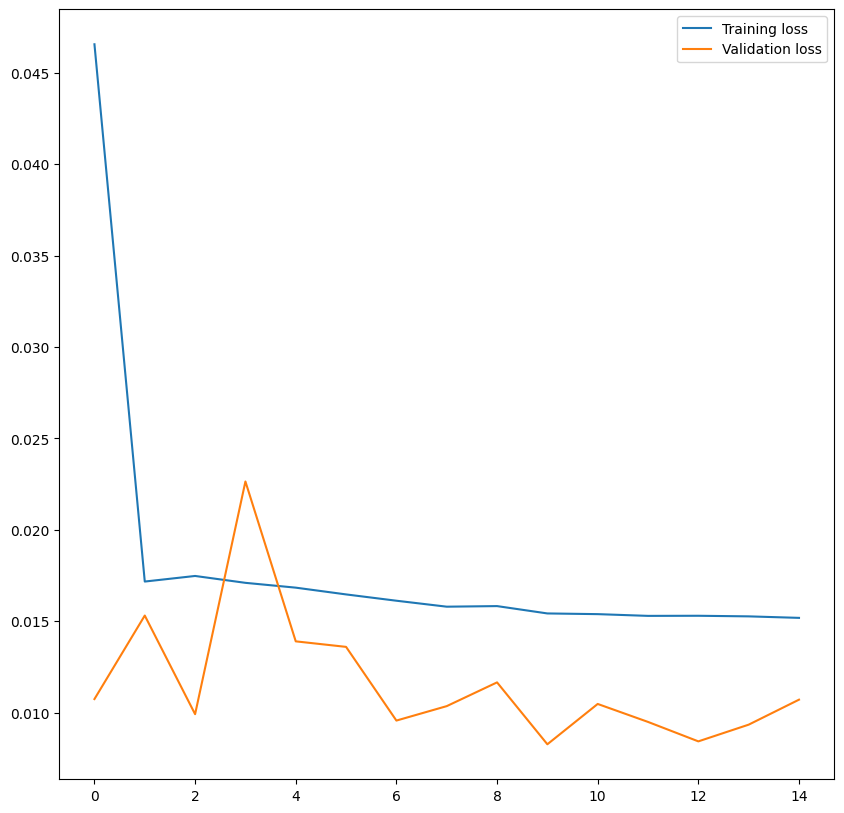

In [6]:
train_log, val_log = trainer.train(with_pde = True)
fig = plt.figure(figsize=(10,10), facecolor='w')
p1, = plt.plot(np.arange(epochs), train_log)
p2, = plt.plot(np.arange(epochs), val_log)
plt.legend([p1, p2], ['Training loss', 'Validation loss'])
plt.show()

In [7]:
def save_model(model,conf,filepath):
    save_info = {
        'model': model.state_dict(),
        'config':conf
    }

    torch.save(save_info, filepath)
    print(f"save the model to {filepath}")

conf = {'x_size': x_size,
        'z_size': z_size,
        'num_hidden': num_hidden,
        'hidden_size': hidden_size,
        'activation': activation,
        'normalizer': normalizer
        }

# save_model(Main_Network, conf, 'models/old_method')
torch.save(main_net, 'models/old_method')

In [2]:
#------------- RevDuff ------------- 
M5_diag = np.diag([-1,-2,-3,-4,-5])    # Choose M matrix
K5_diag = np.array([[1,1,1,1,1]]).T    # Choose K matrix
sys_dim5 = Systems.RevDuff(5, add_noise=False, noise_std=0.1)

N = 1000
a = 0
b = 50

observer2 = Observer(sys_dim5, M5_diag, K5_diag, main_net, a, b, N, init_z_zero=True)

ic = np.array([[0.5, 0.5]])
#sys_dim5.toggle_noise()
x1, x1_hat, t1, error1 = observer2.simulate(ic, add_noise = False)

fig = plt.figure(figsize = (8,8), facecolor='w')
p1, = plt.plot(x1_hat[:,0], x1_hat[:,1])
p2, = plt.plot(x1[:,0], x1[:,1])
plt.legend([p1, p2], ['Estimate', 'Ground Truth'])
plt.show()

NameError: name 'np' is not defined

In [12]:
fig.savefig('/Applications/Programming/Machine Learning/DF Internship/Plots/VdP/Noise_dimtest/Dim 3', dpi=300, transparent = False, bbox_inches = 'tight', facecolor = 'w')

In [3]:
#Kuramoto
coupling = 3

A = np.array([[0.82609078, 0.766099  , 0.04770744, 0.95634223, 0.48535484, 0.82770635, 0.82568269, 0.41482854, 0.10805105, 0.84533148],
                [0.16793279, 0.52216174, 0.32375506, 0.21255903, 0.74318917, 0.27801737, 0.62963795, 0.46563399, 0.87285444, 0.44818149],
                [0.85739688, 0.35466085, 0.23081837, 0.77816442, 0.44434047, 0.04087587, 0.96132654, 0.20077639, 0.35555799, 0.5465003 ],
                [0.66843566, 0.63740146, 0.92209938, 0.83202012, 0.11184414, 0.60635776, 0.70997797, 0.85543721, 0.97555328, 0.59325376],
                [0.35215001, 0.01401137, 0.49319654, 0.17891016, 0.0477552 , 0.85102004, 0.95226833, 0.60082744, 0.80278956, 0.56294354],
                [0.63712071, 0.12634065, 0.71471804, 0.4522626 , 0.82374189, 0.42226771, 0.71647475, 0.70623256, 0.66294877, 0.40769281],
                [0.485451  , 0.7179554 , 0.00683135, 0.76084085, 0.71155059, 0.65390833, 0.55031198, 0.94644044, 0.84509827, 0.29303649],
                [0.00997047, 0.7187184 , 0.84228867, 0.07802682, 0.2649064 , 0.72994764, 0.94594025, 0.50939704, 0.78263394, 0.3596041 ],
                [0.95868957, 0.89330904, 0.36732745, 0.41224862, 0.23902724, 0.81451302, 0.06999864, 0.49742364, 0.40118135, 0.23091774],
                [0.64234836, 0.89619788, 0.0335701 , 0.41857516, 0.19653272,0.63108802, 0.47687404, 0.89418281, 0.26760051, 0.58927806]])

kuramoto = Systems.Kuramoto(10, coupling, adj_mat = A, noise_process_std=0.02, noise_measurement_std=0.02)

a = np.ones([21,1])
b = np.eye(5)
K = np.kron(a,b)

a = np.diag(np.linspace(15, 20, 21))
M = -np.kron(a,b)

a = 0
b = 20
N = 1000

model1 = torch.load('/Applications/Programming/Machine Learning/DF Internship/Models/Kuramoto/PDE_tuned2') 

observer1 = Observer_old(kuramoto, M, K, model1, a, b, N, init_z_zero=False)

# sample_space = np.array([[-2, 2], [-2, 2], [-2, 2],[-2, 2], [-2, 2], [-2, 2],[-2, 2], [-2, 2], [-2, 2],[-2, 2]]) 
# threshold = observer1.get_FDI_threshold(sample_space, 50)
# print(threshold)
threshold = 7

In [2]:
#observer2 = Observer(kuramoto, M, K, model2, a, b, N)
fault1 = MeasurementInjectionFault(5, 10, 2, ['y5'], repeat_every = None)
fault2 = SensorFailureFault(10, 15, ['y4'])

ic = np.random.rand(1,10)*2
x1, x1_hat, t, error, y = observer1.simulate(ic, add_noise = True, faults = [fault1])

y = y[0]
err = np.abs(y[:,0:5] - x1_hat[:,0:5])

# Take the residual derivative    
# dt = (b-a)/N
# err = np.diff(err, axis = 0)/dt
# err = np.append(err, np.zeros([1,err.shape[1]]), axis = 0)

# Plot all errors
fig = plt.figure(figsize = (8,8), facecolor='w')
p1, = plt.plot(t, err[:,0])
p2, = plt.plot(t, err[:,1])
p3, = plt.plot(t, err[:,2])
p4, = plt.plot(t, err[:,3])
p5, = plt.plot(t, err[:,4])
#plt.axhline(y = threshold, color = 'magenta')
plt.legend([p1,p2,p3,p4,p5], ['y1_res','y2_res','y3_res','y4_res','y5_res'])
#plt.title('Fault injected into y1')
plt.show()
#fig.savefig('/Applications/Programming/Machine Learning/DF Internship/Plots/Kuramoto/fault_y1', dpi=300, transparent = False, bbox_inches = 'tight', facecolor = 'w')

# Plot single state
col = 2
fig = plt.figure(figsize = (8,8), facecolor='w')
p1, = plt.plot(t, np.sin(y[:,col]))
#p1, = plt.plot(t, y[:,col])
p2, = plt.plot(t, np.sin(x1_hat[:,col]))
plt.legend([p1, p2], ['y', 'y_hat'])
plt.title('Estimate')
plt.show()

# fig = plt.figure(figsize = (10,10), facecolor='w')
# p1, = plt.plot(t, np.sin(x1[:,col]))
# p2, = plt.plot(t, np.sin(x1_hat[:,col]))
# plt.legend([p1, p2], ['x', 'x_hat'])
# plt.title('Estimate')
# plt.show()

NameError: name 'observer1' is not defined

0.26330605302203564


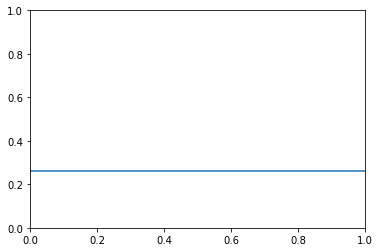

In [9]:
t = np.arange(0,10,1)
print(threshold)
plt.axhline(y = threshold)

/Users/johncao/opt/anaconda3/lib/python3.8/site-packages/mpl_toolkits/mplot3d/proj3d.py:136: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  return np.array([xs, ys, zs, np.ones_like(xs)])
/Users/johncao/opt/anaconda3/lib/python3.8/site-packages/mpl_toolkits/mplot3d/proj3d.py:136: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return np.array([xs, ys, zs, np.ones_like(

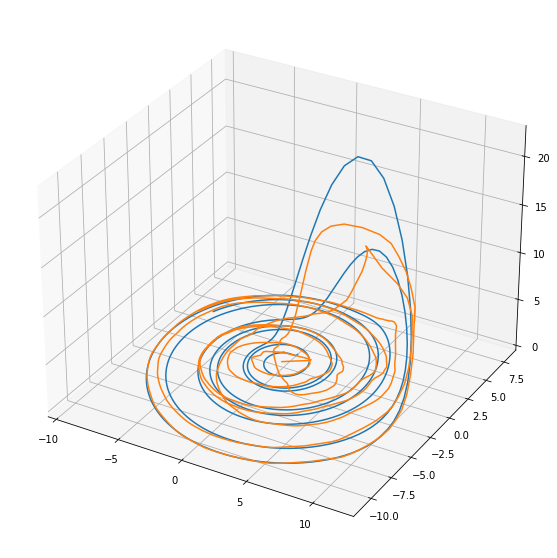

In [8]:
#------------- Chua ------------- 
mat = spio.loadmat('/Applications/Programming/Machine Learning/DF Internship/MK_data/Chua_ML', squeeze_me=True)
M = mat['M']
K = np.expand_dims(mat['L'], axis = 0).T


#np.random.seed(0)
ic = np.random.rand(1,3)*1
#ic = np.array([[0.4, 0.4, 0.4]])
# M = np.diag([-1,-2,-3,-4])    # Choose M matrix
# K = np.array([[1,1,1,1]]).T    # Choose K matrix
# alpha = 11.81
# beta = 14.9
# gamma = 0.29
# sys_dim4 = Systems.Chua(alpha, beta, gamma, -1.14, -0.71)

sys_dim4 = rossler
z_sys4 = System_z(M, K, sys_dim4)
a = 0
b = 50
#sys_dim4.toggle_noise()
#model = torch.load('/Applications/Programming/Machine Learning/DF Internship/MATLAB_data/Chua/50ic_1000N_-0.1_0.1_15ep_SEED5_lr0.0001_bs32_dim5_3hidden_chua')
observer1 = Observer_old(sys_dim4, z_sys4, main_net, a, b, N)
x1, x1_hat, t1, error1 = observer1.simulate(ic, noise_std = 1, add_noise = False)

fig = plt.figure(figsize = (10,10), facecolor='w')
# plt.plot(t1, x1_hat[:,0])
# plt.plot(t1, x1[:,0])
ax = plt.axes(projection = '3d')
ax.plot3D(x1[:,0], x1[:,1], x1[:,2])
ax.plot3D(x1_hat[:,0], x1_hat[:,1], x1_hat[:,2])
plt.show()
mdict = {'x':x1.numpy(), 'x_hat':x1_hat.numpy()}
#spio.savemat('/Applications/Programming/Machine Learning/DF Internship/Experiments/Rossler_noise/rossler_system_noise.mat',mdict)


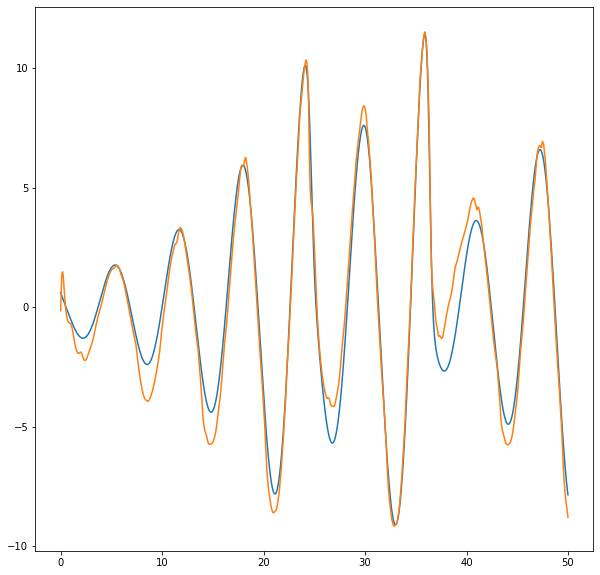

In [9]:
fig = plt.figure(figsize = (10,10), facecolor='w')
plt.plot(t1, x1[:,0])
plt.plot(t1, x1_hat[:,0])
plt.show()

In [19]:
ic

array([[0.38882506, 1.17765289]])

In [29]:
mdict = {'states':x1.numpy()}
spio.savemat('/Applications/Programming/Machine Learning/DF Internship/MATLAB_data/VdP/vdp_outside_truth.mat',mdict)

In [8]:
mat = spio.loadmat('/Applications/Programming/Machine Learning/DF Internship/MK_data/SIR_net', squeeze_me=True)
M = mat['A']
K = mat['B']
C = mat['C']
D = mat['D']
W = mat['W']
G = mat['G']
net_sir = Systems.Network_SIR(D, W, G, C)
limits_S = np.concatenate((np.zeros([5,1]), np.ones([5,1])), axis = 1)*0.8
limits_I = np.concatenate((np.zeros([5,1]), np.ones([5,1])), axis = 1)*0.2
limits = np.concatenate((limits_S, limits_I), axis = 0)
model = torch.load('/Applications/Programming/Machine Learning/DF Internship/MATLAB_data/net_sir/net_sir'  )
a = 0
b = 100
z_sys = System_z(M, K, net_sir)
observer = Observer_old(net_sir, z_sys, model)
#ic = np.expand_dims(net_sir.sample_ic(limits, 50, 123)[2], axis = 0)
ic = np.array([[0.004, 0.356, 0.348, 0.476, 0.572, 0.123, 0.031, 0.183, 0.157, 0.121]])
x1, x1_hat, t1, error1 = observer.simulate(a, b, 5000, ic, 0,0, add_noise=True)

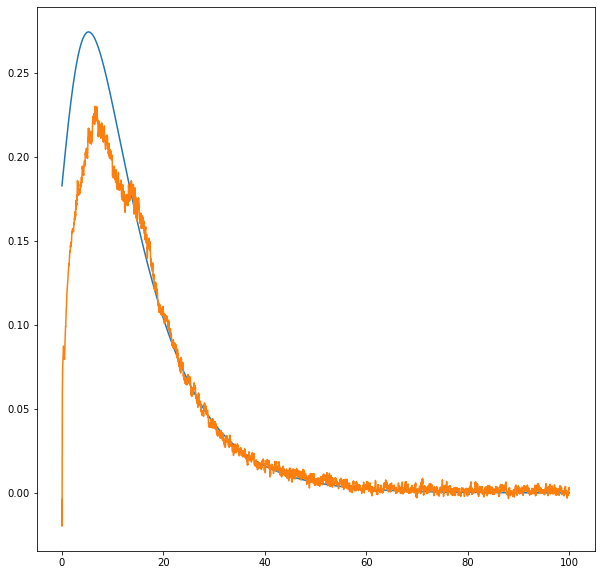

In [9]:
i = 7
fig = plt.figure(figsize = (10,10), facecolor = 'w')
plt.plot(t1, x1[:,i])
plt.plot(t1, x1_hat[:,i])
plt.show()

In [7]:
main_net.state_dict()

OrderedDict([('net1.layers.0.weight',
              tensor([[ 0.1314, -0.2397, -0.0109],
                      [ 0.3127,  0.5066,  0.5571],
                      [-0.3715,  0.4414,  0.0201],
                      [-0.1245,  0.5142,  0.1399],
                      [-0.5371, -0.3716,  0.0349],
                      [-0.0230, -0.0158, -0.2629],
                      [-0.0726,  0.1584,  0.2944],
                      [ 0.3772,  0.4848,  0.3451],
                      [-0.1062, -0.4850,  0.5233],
                      [ 0.3389,  0.5501,  0.1437],
                      [ 0.0811,  0.1373,  0.5076],
                      [ 0.3232,  0.2900, -0.0655],
                      [-0.2834,  0.1546,  0.4942],
                      [-0.0110,  0.4699, -0.4580],
                      [ 0.2592,  0.1286, -0.3327],
                      [ 0.2147, -0.2199,  0.4990],
                      [ 0.3669, -0.4266,  0.3497],
                      [ 0.0248,  0.2616,  0.3168],
                      [-0.0987, -0.2419, -0.

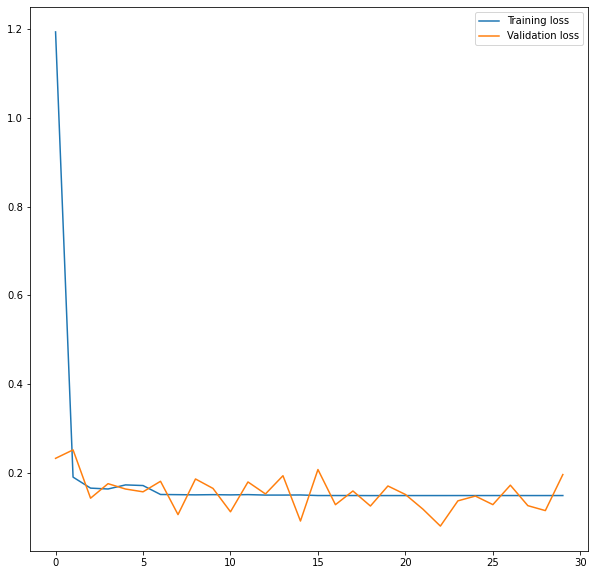

In [8]:
fig = plt.figure(figsize=(10,10), facecolor='w')
p1, = plt.plot(np.arange(epochs), train_log)
p2, = plt.plot(np.arange(epochs), val_log)
plt.legend([p1, p2], ['Training loss', 'Validation loss'])
plt.show()